# Task 2 — Time Series Forecasting Models (Initial Progress: ARIMA/SARIMA)

**GMF Investments — Time Series Forecasting for Portfolio Management Optimization**

This notebook implements the first forecasting model for TSLA's closing price: a
classical **ARIMA** model selected via `pmdarima.auto_arima`. The chronological
train/test split, model fitting, forecasting, and evaluation (MAE, RMSE, MAPE) are
completed here. The LSTM deep-learning model and full model comparison will be
added for the final submission.

In [1]:
import sys
sys.path.append("..")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import pmdarima as pm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)


## 1. Load Processed Data

In [2]:
tsla = pd.read_csv("../data/processed/TSLA_processed.csv", index_col=0, parse_dates=True)
tsla = tsla[["Adj Close"]].rename(columns={"Adj Close": "close"})
tsla.head()


,close
Date,
2015-01-02,14.620667
2015-01-05,14.006000
2015-01-06,14.085333
2015-01-07,14.063333
2015-01-08,14.041333


## 2. Chronological Train/Test Split

Per the project instructions, the split preserves temporal order — no shuffling.
Training: **2015-01-01 to 2024-12-31**. Testing: **2025-01-01 onward** (held-out,
most recent data).

Train: 2015-01-02 -> 2024-12-31 (2608 obs)
Test:  2025-01-01 -> 2026-06-29 (389 obs)


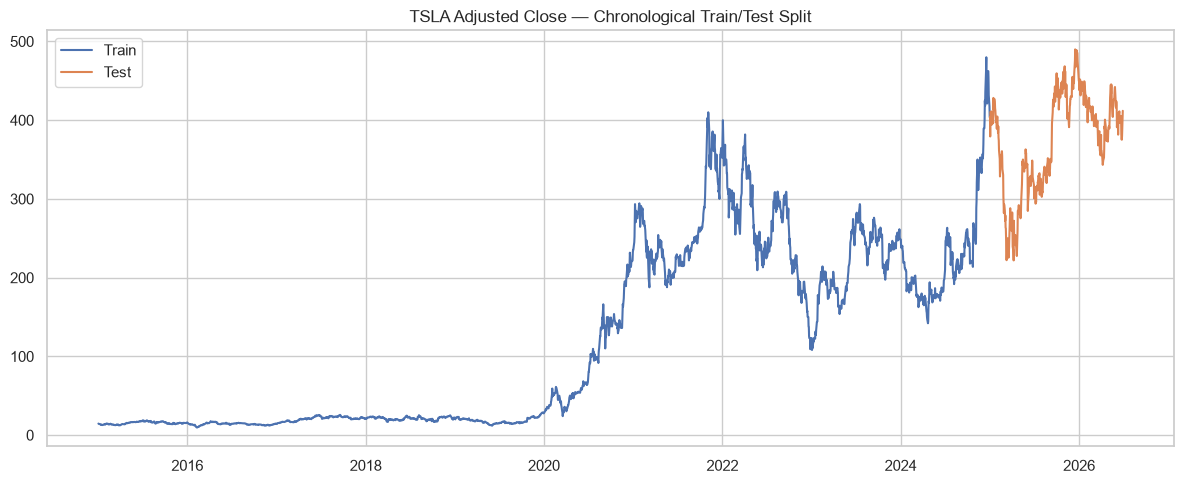

In [3]:
train = tsla.loc[:"2024-12-31"]
test = tsla.loc["2025-01-01":]

print(f"Train: {train.index.min().date()} -> {train.index.max().date()} ({len(train)} obs)")
print(f"Test:  {test.index.min().date()} -> {test.index.max().date()} ({len(test)} obs)")

fig, ax = plt.subplots()
ax.plot(train.index, train["close"], label="Train")
ax.plot(test.index, test["close"], label="Test")
ax.set_title("TSLA Adjusted Close — Chronological Train/Test Split")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/06_train_test_split.png", dpi=150)
plt.show()


## 3. ACF/PACF and Differencing

Task 1 established that TSLA's price level is non-stationary (ADF test) while its
daily returns are stationary — i.e. one order of differencing (**d = 1**) is required.
The ACF/PACF plots below are shown on the differenced (first-difference) series to
guide the choice of AR/MA order, and `auto_arima` is then used to confirm the optimal
(p, d, q) by minimizing AIC.

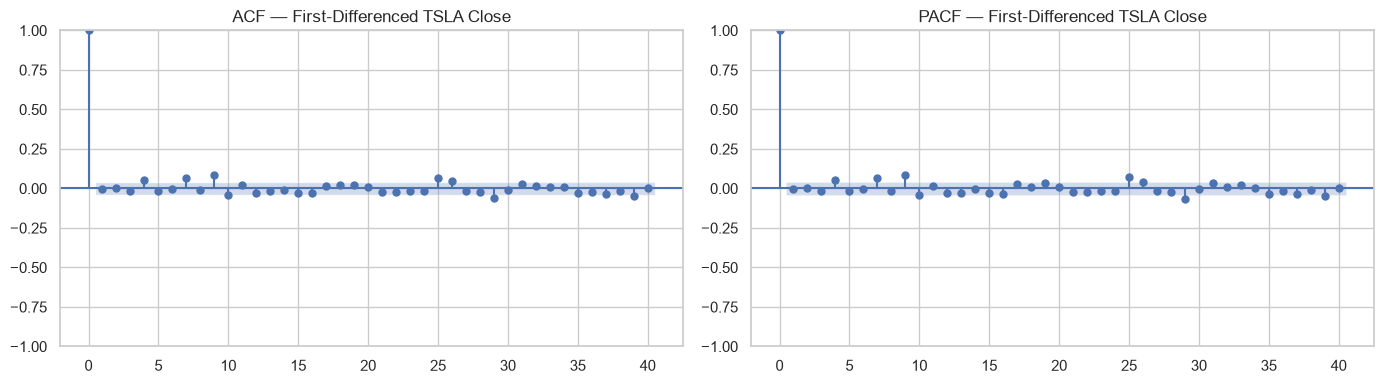

In [4]:
diff_close = train["close"].diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(diff_close, lags=40, ax=axes[0])
axes[0].set_title("ACF — First-Differenced TSLA Close")
plot_pacf(diff_close, lags=40, ax=axes[1], method="ywm")
axes[1].set_title("PACF — First-Differenced TSLA Close")
plt.tight_layout()
plt.savefig("../reports/figures/07_acf_pacf.png", dpi=150)
plt.show()


## 4. Fit ARIMA via `auto_arima`

In [5]:
auto_model = pm.auto_arima(
    train["close"],
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    d=None,               # let auto_arima determine d via KPSS/ADF-style test
    seasonal=False,       # daily stock price: no strong deterministic seasonality
    stepwise=True,
    suppress_warnings=True,
    trace=True,
    information_criterion="aic",
)
print(auto_model.summary())


Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16873.591, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16875.541, Time=0.07 sec


 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16875.541, Time=0.07 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16873.127, Time=0.05 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16877.541, Time=0.12 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.381 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2608
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -8435.563
Date:                Sat, 04 Jul 2026   AIC                          16873.127
Time:                        11:40:57   BIC                          16878.993
Sample:                    01-02-2015   HQIC                         16875.252
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------

In [6]:
order = auto_model.order
print(f"Selected ARIMA order (p, d, q) = {order}")


Selected ARIMA order (p, d, q) = (0, 1, 0)


## 5. Fit Final ARIMA Model on Training Data and Forecast the Test Period

In [7]:
final_model = ARIMA(train["close"], order=order)
final_fit = final_model.fit()

n_periods = len(test)
forecast_result = final_fit.get_forecast(steps=n_periods)
forecast_mean = forecast_result.predicted_mean
forecast_ci = forecast_result.conf_int(alpha=0.05)

forecast_mean.index = test.index
forecast_ci.index = test.index
forecast_ci.columns = ["lower", "upper"]


/Users/selam/Desktop/Ten Academy AI/week 9/portfolio-optimization/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/Users/selam/Desktop/Ten Academy AI/week 9/portfolio-optimization/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/Users/selam/Desktop/Ten Academy AI/week 9/portfolio-optimization/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


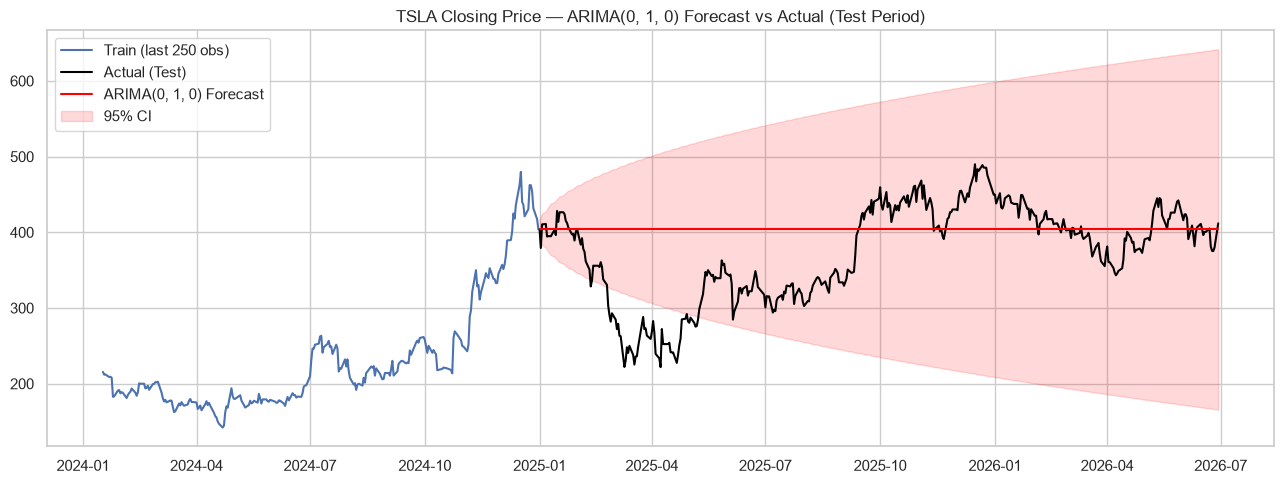

In [8]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(train.index[-250:], train["close"].iloc[-250:], label="Train (last 250 obs)")
ax.plot(test.index, test["close"], label="Actual (Test)", color="black")
ax.plot(test.index, forecast_mean, label=f"ARIMA{order} Forecast", color="red")
ax.fill_between(test.index, forecast_ci["lower"], forecast_ci["upper"], color="red", alpha=0.15, label="95% CI")
ax.set_title(f"TSLA Closing Price — ARIMA{order} Forecast vs Actual (Test Period)")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/08_arima_forecast_vs_actual.png", dpi=150)
plt.show()


## 6. Evaluate Model Performance

In [9]:
mae = mean_absolute_error(test["close"], forecast_mean)
rmse = np.sqrt(mean_squared_error(test["close"], forecast_mean))
mape = np.mean(np.abs((test["close"] - forecast_mean) / test["close"])) * 100

metrics = pd.DataFrame(
    {"MAE": [mae], "RMSE": [rmse], "MAPE (%)": [mape]},
    index=[f"ARIMA{order}"],
)
metrics.to_csv("../data/processed/arima_metrics.csv")
metrics


,MAE,RMSE,MAPE (%)
"ARIMA(0, 1, 0)",54.151953,70.196786,17.112171


**Discussion (initial):** The `auto_arima` search selected the order shown above by
minimizing AIC on the training data. Because TSLA's price is non-stationary and close to a
random walk, the fitted ARIMA model's point forecast is close to a slowly drifting/flat
projection from the end of the training period, while the confidence interval widens quickly
over the ~18-month test horizon. This is expected given the Efficient Market Hypothesis
discussion in Task 1: point-forecasting exact future prices with only historical price data
is fundamentally hard, and the honest signal is in how fast forecast uncertainty grows, not
in the point forecast itself. A full discussion comparing ARIMA against an LSTM model will be
completed in the final submission, once the LSTM (Task 2, remaining) and forecast horizon
analysis (Task 3) are implemented.

## 7. Next Steps (Remaining for Final Submission)

- Implement the LSTM model (sequence windowing, architecture, training) for TSLA
- Compare ARIMA vs. LSTM on MAE / RMSE / MAPE and select the best-performing model
- Generate 6-12 month future forecasts with confidence intervals (Task 3)
- Build the Efficient Frontier and optimal portfolio (Task 4)
- Backtest the strategy against the 60/40 SPY/BND benchmark (Task 5)